# Week 2 — Introduction to Machine Learning

Combined notebook covering all Week 2 topics: Linear Regression, Multivariate
Regression, Subset Selection (Best Subset + Stepwise), Shrinkage Methods
(Ridge/Lasso), Principal Components Regression, and Partial Least Squares.

Each section has a brief description followed by runnable code.


---
## 1. Linear Regression

Fits a straight line `y = β0 + β1*x` to data by minimizing the sum of squared
residuals (OLS). Simplest baseline regression model, used here on a toy
"study hours vs marks" dataset with train/test split, evaluation metrics
(MSE, RMSE, MAE, R²), fitted-line plot, and residual analysis.


Intercept: 6.5402
Slope: 7.7129
MSE: 16.6631
RMSE: 4.0820
MAE: 2.9202
R2: 0.9633


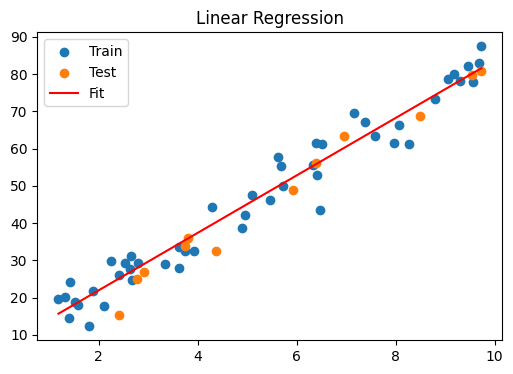

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)

# Toy dataset
X = np.random.uniform(1, 10, 60).reshape(-1, 1)
y = 5 + 8 * X.flatten() + np.random.normal(0, 5, 60)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Intercept: {model.intercept_:.4f}")
print(f"Slope: {model.coef_[0]:.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R2: {r2_score(y_test, y_pred):.4f}")

plt.figure(figsize=(6, 4))
plt.scatter(X_train, y_train, label="Train")
plt.scatter(X_test, y_test, label="Test")
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
plt.plot(x_line, model.predict(x_line), color="red", label="Fit")
plt.legend()
plt.title("Linear Regression")
plt.show()

---
## 2. Multivariate Regression

Extends linear regression to multiple predictors: `y = β0 + β1*x1 + ... + βp*xp`.
Solved via the normal equation. Below we fit a 3-predictor model (with one
predictor deliberately correlated with another), report Adjusted R², and check
multicollinearity using VIF (Variance Inflation Factor).


In [2]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

np.random.seed(42)

n = 200
x1 = np.random.normal(50, 10, n)
x2 = x1 * 0.8 + np.random.normal(0, 3, n)   # correlated with x1
x3 = np.random.normal(20, 5, n)
y_mv = 4 + 2.5 * x1 + 1.2 * x3 + np.random.normal(0, 5, n)

df = pd.DataFrame({"x1": x1, "x2": x2, "x3": x3, "y": y_mv})
X_mv = df[["x1", "x2", "x3"]]

X_train_mv, X_test_mv, y_train_mv, y_test_mv = train_test_split(
    X_mv, df["y"], test_size=0.2, random_state=42
)

model_mv = LinearRegression()
model_mv.fit(X_train_mv, y_train_mv)
y_pred_mv = model_mv.predict(X_test_mv)

n_test, p = X_test_mv.shape
r2_mv = r2_score(y_test_mv, y_pred_mv)
adj_r2 = 1 - (1 - r2_mv) * (n_test - 1) / (n_test - p - 1)

print("Coefficients:", dict(zip(X_mv.columns, model_mv.coef_)))
print(f"Intercept: {model_mv.intercept_:.4f}")
print(f"MSE: {mean_squared_error(y_test_mv, y_pred_mv):.4f}")
print(f"R2: {r2_mv:.4f}  Adjusted R2: {adj_r2:.4f}")

vif = pd.DataFrame()
vif["feature"] = X_mv.columns
vif["VIF"] = [variance_inflation_factor(X_mv.values, i) for i in range(X_mv.shape[1])]
print(vif)

Coefficients: {'x1': np.float64(2.778077840934982), 'x2': np.float64(-0.28489277467705687), 'x3': np.float64(1.2867806292675816)}
Intercept: 0.0526
MSE: 21.5108
R2: 0.9572  Adjusted R2: 0.9537
  feature       VIF
0      x1  7.883871
1      x2  7.880233
2      x3  1.018752


---
## 3. Subset Selection — Best Subset

Tries every possible combination of predictors, picks the best model for each
subset size (by RSS), then chooses the final model size using Adjusted R²
(which penalizes extra predictors). Exhaustive — only feasible for small `p`.


In [3]:
from itertools import combinations

np.random.seed(42)
n = 150
X_bs = pd.DataFrame({
    "x1": np.random.normal(size=n),
    "x2": np.random.normal(size=n),
    "x3": np.random.normal(size=n),
    "x4": np.random.normal(size=n),
})
y_bs = 3 + 2 * X_bs["x1"] - 1.5 * X_bs["x3"] + np.random.normal(0, 1, n)

def best_subset(X, y):
    best = {}
    for k in range(1, X.shape[1] + 1):
        best_rss = np.inf
        best_cols = None
        for cols in combinations(X.columns, k):
            m = LinearRegression().fit(X[list(cols)], y)
            pred = m.predict(X[list(cols)])
            rss = np.sum((y - pred) ** 2)
            if rss < best_rss:
                best_rss = rss
                best_cols = cols
        best[k] = (best_cols, best_rss)
    return best

results = best_subset(X_bs, y_bs)
for k, (cols, rss) in results.items():
    print(f"k={k}: {cols}  RSS={rss:.2f}")

n_obs = X_bs.shape[0]
best_k, best_score = None, -np.inf
for k, (cols, rss) in results.items():
    tss = np.sum((y_bs - y_bs.mean()) ** 2)
    r2 = 1 - rss / tss
    adj_r2 = 1 - (1 - r2) * (n_obs - 1) / (n_obs - k - 1)
    if adj_r2 > best_score:
        best_score, best_k = adj_r2, k

print(f"\nSelected model: k={best_k}, predictors={results[best_k][0]}, Adj R2={best_score:.4f}")

k=1: ('x1',)  RSS=438.20
k=2: ('x1', 'x3')  RSS=158.46
k=3: ('x1', 'x2', 'x3')  RSS=156.89
k=4: ('x1', 'x2', 'x3', 'x4')  RSS=156.87

Selected model: k=3, predictors=('x1', 'x2', 'x3'), Adj R2=0.8377


---
## 4. Subset Selection — Forward & Backward Stepwise

Greedy alternatives to best subset selection, much cheaper computationally.
**Forward**: starts empty, adds one predictor at a time (best improvement in
CV score). **Backward**: starts with all predictors, removes one at a time
(least useful). Both evaluated here using 5-fold cross-validated MSE.


In [4]:
from sklearn.model_selection import cross_val_score

np.random.seed(42)
n = 150
X_sw = pd.DataFrame({
    "x1": np.random.normal(size=n),
    "x2": np.random.normal(size=n),
    "x3": np.random.normal(size=n),
    "x4": np.random.normal(size=n),
    "x5": np.random.normal(size=n),
})
y_sw = 3 + 2 * X_sw["x1"] - 1.5 * X_sw["x3"] + 0.8 * X_sw["x5"] + np.random.normal(0, 1, n)

def cv_score(cols):
    m = LinearRegression()
    scores = cross_val_score(m, X_sw[cols], y_sw, cv=5, scoring="neg_mean_squared_error")
    return -scores.mean()

def forward_stepwise(X, y):
    remaining = list(X.columns)
    selected = []
    history = []
    while remaining:
        scores = [(cv_score(selected + [col]), col) for col in remaining]
        scores.sort()
        best_score, best_col = scores[0]
        selected.append(best_col)
        remaining.remove(best_col)
        history.append((list(selected), best_score))
    return history

def backward_stepwise(X, y):
    selected = list(X.columns)
    history = [(list(selected), cv_score(selected))]
    while len(selected) > 1:
        scores = []
        for col in selected:
            trial = [c for c in selected if c != col]
            scores.append((cv_score(trial), trial))
        scores.sort(key=lambda t: t[0])
        best_score, best_set = scores[0]
        selected = best_set
        history.append((list(selected), best_score))
    return history

print("Forward Stepwise:")
for cols, score in forward_stepwise(X_sw, y_sw):
    print(f"  {cols}  CV-MSE={score:.4f}")

print("\nBackward Stepwise:")
for cols, score in backward_stepwise(X_sw, y_sw):
    print(f"  {cols}  CV-MSE={score:.4f}")

Forward Stepwise:


  ['x1']  CV-MSE=3.2866
  ['x1', 'x3']  CV-MSE=1.7556
  ['x1', 'x3', 'x5']  CV-MSE=0.9324
  ['x1', 'x3', 'x5', 'x4']  CV-MSE=0.9303
  ['x1', 'x3', 'x5', 'x4', 'x2']  CV-MSE=0.9503

Backward Stepwise:


  ['x1', 'x2', 'x3', 'x4', 'x5']  CV-MSE=0.9503
  ['x1', 'x3', 'x4', 'x5']  CV-MSE=0.9303
  ['x1', 'x3', 'x5']  CV-MSE=0.9324
  ['x1', 'x3']  CV-MSE=1.7556
  ['x1']  CV-MSE=3.2866


---
## 5. Shrinkage Methods — Ridge & Lasso

Instead of picking a subset, keep all predictors but shrink coefficients
toward zero. **Ridge** (L2 penalty) shrinks but never zeroes coefficients —
good for correlated predictors. **Lasso** (L1 penalty) can zero coefficients
out entirely — performs automatic feature selection. Best λ chosen via
cross-validation (`RidgeCV`, `LassoCV`).


Best Ridge alpha: 1.151395399326447
Ridge coefficients: [ 2.595 -2.076  0.014  0.059  1.412  0.023 -0.242  0.073  0.04   0.811]
Ridge Test MSE: 1.1623686738678949

Best Lasso alpha: 0.06866488450043001
Lasso coefficients: [ 2.582e+00 -2.051e+00  0.000e+00  0.000e+00  1.370e+00  0.000e+00
 -1.490e-01  0.000e+00  1.000e-03  7.610e-01]
Lasso Test MSE: 1.0283576424932406
Nonzero Lasso coefficients: 6


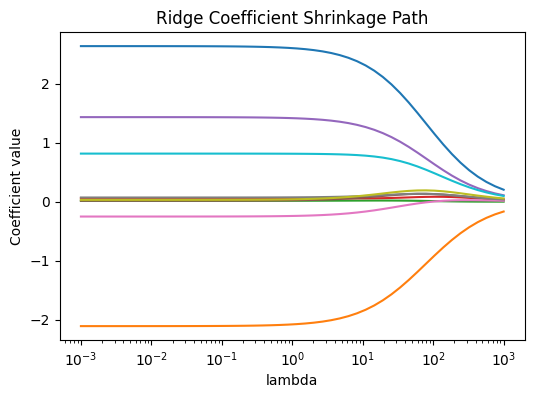

In [5]:
from sklearn.linear_model import Ridge, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
n, p = 100, 10
X_shr = np.random.normal(size=(n, p))
true_beta = np.array([3, -2, 0, 0, 1.5, 0, 0, 0, 0, 0.8])
y_shr = X_shr @ true_beta + np.random.normal(0, 1, n)

scaler = StandardScaler()
X_shr_scaled = scaler.fit_transform(X_shr)
X_train_shr, X_test_shr, y_train_shr, y_test_shr = train_test_split(
    X_shr_scaled, y_shr, test_size=0.2, random_state=42
)

lambdas = np.logspace(-3, 3, 50)

ridge_cv = RidgeCV(alphas=lambdas, cv=5).fit(X_train_shr, y_train_shr)
print("Best Ridge alpha:", ridge_cv.alpha_)
print("Ridge coefficients:", np.round(ridge_cv.coef_, 3))
print("Ridge Test MSE:", mean_squared_error(y_test_shr, ridge_cv.predict(X_test_shr)))

lasso_cv = LassoCV(alphas=lambdas, cv=5, max_iter=10000).fit(X_train_shr, y_train_shr)
print("\nBest Lasso alpha:", lasso_cv.alpha_)
print("Lasso coefficients:", np.round(lasso_cv.coef_, 3))
print("Lasso Test MSE:", mean_squared_error(y_test_shr, lasso_cv.predict(X_test_shr)))
print("Nonzero Lasso coefficients:", np.sum(lasso_cv.coef_ != 0))

coefs_ridge = [Ridge(alpha=a).fit(X_train_shr, y_train_shr).coef_ for a in lambdas]
plt.figure(figsize=(6, 4))
plt.plot(lambdas, coefs_ridge)
plt.xscale("log")
plt.xlabel("lambda")
plt.ylabel("Coefficient value")
plt.title("Ridge Coefficient Shrinkage Path")
plt.show()

---
## 6. Principal Components Regression (PCR)

Reduces dimensionality first: run PCA on the predictors to get uncorrelated
components, then regress `y` on the top `M` components. Removes
multicollinearity entirely, but component selection is **unsupervised**
(doesn't look at `y`). Number of components `M` chosen via cross-validation.


In [6]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

np.random.seed(42)
n, p = 200, 15
X_pcr = np.random.normal(size=(n, p))
y_pcr = X_pcr[:, 0] * 3 + X_pcr[:, 1] * 2 + np.random.normal(0, 1, n)

X_train_pcr, X_test_pcr, y_train_pcr, y_test_pcr = train_test_split(
    X_pcr, y_pcr, test_size=0.2, random_state=42
)

best_m, best_mse = None, np.inf
for m in range(1, p + 1):
    pipe = make_pipeline(StandardScaler(), PCA(n_components=m), LinearRegression())
    scores = cross_val_score(pipe, X_train_pcr, y_train_pcr, cv=5, scoring="neg_mean_squared_error")
    mse = -scores.mean()
    if mse < best_mse:
        best_mse, best_m = mse, m

print(f"Best number of components: {best_m}, CV-MSE: {best_mse:.4f}")

final_pipe = make_pipeline(StandardScaler(), PCA(n_components=best_m), LinearRegression())
final_pipe.fit(X_train_pcr, y_train_pcr)
y_pred_pcr = final_pipe.predict(X_test_pcr)
pcr_test_mse = mean_squared_error(y_test_pcr, y_pred_pcr)
print("Test MSE:", pcr_test_mse)

pca_step = final_pipe.named_steps["pca"]
print("Explained variance ratio per component:", np.round(pca_step.explained_variance_ratio_, 3))

Best number of components: 15, CV-MSE: 1.0570
Test MSE: 1.663988803087431
Explained variance ratio per component: [0.098 0.091 0.09  0.087 0.079 0.076 0.072 0.065 0.059 0.055 0.051 0.049
 0.047 0.042 0.039]


---
## 7. Partial Least Squares (PLS)

Like PCR, but components are built **using `y`** as well as `X` — each
predictor is weighted by how strongly it relates to the response. Usually
achieves lower bias than PCR since components are supervised, though can be
more prone to overfitting. Same dataset as PCR above, for a direct
apples-to-apples comparison.


In [7]:
from sklearn.cross_decomposition import PLSRegression

# Reuse the PCR dataset (X_pcr, y_pcr) for a fair comparison
X_pls_scaled = StandardScaler().fit_transform(X_pcr)
X_train_pls, X_test_pls, y_train_pls, y_test_pls = train_test_split(
    X_pls_scaled, y_pcr, test_size=0.2, random_state=42
)

best_m_pls, best_mse_pls = None, np.inf
for m in range(1, p + 1):
    pls = PLSRegression(n_components=m)
    scores = cross_val_score(pls, X_train_pls, y_train_pls, cv=5, scoring="neg_mean_squared_error")
    mse = -scores.mean()
    if mse < best_mse_pls:
        best_mse_pls, best_m_pls = mse, m

print(f"Best number of components: {best_m_pls}, CV-MSE: {best_mse_pls:.4f}")

pls_final = PLSRegression(n_components=best_m_pls)
pls_final.fit(X_train_pls, y_train_pls)
y_pred_pls = pls_final.predict(X_test_pls).flatten()
pls_test_mse = mean_squared_error(y_test_pls, y_pred_pls)
print("Test MSE:", pls_test_mse)

print(f"\nPCR Test MSE: {pcr_test_mse:.4f}")
print(f"PLS Test MSE: {pls_test_mse:.4f}")

Best number of components: 5, CV-MSE: 1.0561
Test MSE: 1.6659030249762794

PCR Test MSE: 1.6640
PLS Test MSE: 1.6659


---
## Summary

- **Linear/Multivariate Regression** — baseline OLS models
- **Subset Selection** (Best Subset, Forward/Backward Stepwise) — pick a smaller
  predictor set
- **Shrinkage** (Ridge/Lasso) — keep all predictors, shrink coefficients
  (Lasso can zero them out)
- **PCR/PLS** — reduce dimensionality via derived components before regressing;
  PLS uses `y` to guide component construction, PCR does not
